TEST

In [100]:
from Scripts.data_preprocessing_sber import preprocessing_data_from_sber

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import copy
%matplotlib inline
from typing import Union,TypeVar
from datetime import datetime
import joblib
import sys
import json

import torch
from torch import optim
from torch.autograd import Variable, grad
from torch.utils.data import DataLoader, Dataset
import torch.nn as nn
import torch.nn.functional as F

from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from scipy.special import rel_entr, kl_div
from scipy.spatial.distance import jensenshannon
from scipy.stats import kstest, ks_2samp, wasserstein_distance
import scipy.stats as sts
from tqdm import tqdm

from TRGAN.TRGAN_main_V2 import *
from TRGAN.encoders import *
import TRGAN.TRGAN_train_load_modules as trgan
from TRGAN.evaluation_metrics import *
from TRGAN.methods_comparison import *
from TRGAN.TRGAN_light_preprocessing import *
from TRGAN.data_preprocessing import load_data

import warnings
warnings.filterwarnings("ignore")
plt.style.use('ggplot')
# DEVICE = 'cpu'
DEVICE = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
print(DEVICE)

cuda:0


In [101]:
data = preprocessing_data_from_sber(folder_path=r'Data\Sber\ditry_single')
# data = preprocessing_data_from_sber(folder_path=r'Data\Sber\ditry')

Ищем CSV-файлы в: c:\Users\kiril\TRGAN\Data\Sber\ditry_single
Найдено файлов: 1
Файлы: ['c:\\Users\\kiril\\TRGAN\\Data\\Sber\\ditry_single\\transact1_2K.csv']
Загрузка и обработка файла: c:\Users\kiril\TRGAN\Data\Sber\ditry_single\transact1_2K.csv
Корректная обработка ADDRESS...
Статистика:
  Оффлайн транзакций: 70224 (21.7%)
  Онлайн транзакций: 253620 (78.3%)
  Физических адресов: 70218 (21.7%)
  Виртуальных транзакций: 253620 (78.3%)
Валидация логики обработки ADDRESS:
--------------------------------------------------
Онлайн транзакций: 253620
Онлайн транзакций, помеченных как виртуальные: 253620
Совпадение: 100.0%

Оффлайн транзакций: 70224
Оффлайн с физическими адресами: 70218
Покрытие: 100.0%

Распределение ADDRESS_TYPE:
ADDRESS_TYPE
VIRTUAL     253620
PHYSICAL     67241
OTHER         2977
MISSING          6
Name: count, dtype: int64
Итоговый датафрейм содержит 275259 строк и 36 колонок.


In [102]:
data["CITY"].unique()

array(['VIRTUAL', 'Санкт-Петербург', 'UNKNOWN', 'Павловск', 'Петергоф',
       'Кронштадт', 'Парголово', 'Шушары', 'Ломоносов', 'Сестрорецк',
       'Пушкин', 'Мурино', 'Колпино', 'Стрельна', 'Херсонский',
       'Зеленогорск', 'Виллози', 'Петродворец', 'Порошкино', 'Песочный',
       'Тельмана', 'Новое Девяткино', 'Кудрово', 'Кириши', 'Матокса',
       'Всеволожск', 'Песочное', 'Красное Село', 'Приозерск', 'Отрадное',
       'Шлиссельбург', 'Репино', 'Горелово', 'Сертолово', 'Лебяжье',
       'Гатчина', 'Молодежное', 'Горбунки', 'Чудово', 'Коммунар',
       'Солнечное', 'Калининград', 'Кобралово', 'Куйвози', 'Белоостров',
       'Разбегаево', 'Смолячково', 'Тосно', 'Токсово', 'Храброво',
       'Кисельня', 'Орловка', 'Суоранда', 'Луга', 'Беково', 'Васкелово',
       'Кипень', 'Лисий Нос', 'Большая Яблоновка', 'Металлострой',
       'Лахта', 'Рощино', 'Симагино', 'Борисово'], dtype=object)

In [103]:
data["REGION"].unique()

array(['VIRTUAL', 'Санкт-Петербург', 'UNKNOWN', 'обл Ленинградская',
       'обл Новгородская', 'обл Калининградская'], dtype=object)

In [104]:
data[data["REGION"] == 'UNKNOWN']

,CustomerKey,ID,TRANS_TIME,AMOUNT_EQ,MCC,PAY_AMT,CurrencyName,PaymentSystem,TERMINAL_CODE,ADDRESS,...,IS_PHYSICAL_LOCATION,ADDRESS_DETAIL_LEVEL,HAS_PHYSICAL_ADDRESS,ISVIRTUALTRANSACTION,OFFLINE_WITH_ADDRESS,ONLINE_VIRTUAL,EXCHANGE_RATA,HOUR,MINUTE,SECOND
123045,1006209,394374368,1900-01-01 05:51:23,220.0,8999,220.0,Рубль,MasterCard,P1900018,"ул Малая Садовая, д 1/25, лит А.",...,1,3,1,0,1,0,1.0,5,51,23
60219,1005728,394213062,1900-01-01 14:26:10,22.9,5641,22.9,Рубль,БАНК,M4800088,"Савушкина 116, лит. А",...,1,2,1,0,1,0,1.0,14,26,10
192335,1006800,394390484,1900-01-01 18:07:00,165.0,5812,165.0,Рубль,MasterCard,P4800134,"Средний пр ВО, д. 87, корп. 2, лит А, 3-Н",...,1,5,1,0,1,0,1.0,18,7,0
152611,1006800,394398354,1900-01-01 18:43:42,165.0,5812,165.0,Рубль,MasterCard,P4800134,"Средний пр ВО, д. 87, корп. 2, лит А, 3-Н",...,1,5,1,0,1,0,1.0,18,43,42
242415,1008416,394773289,1900-01-01 10:50:23,74.8,5641,74.8,Рубль,БАНК,M4800100,"пр. Культуры, 41, Лит. А",...,1,3,1,0,1,0,1.0,10,50,23
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2466,1007809,802709301,1900-01-01 17:11:10,75.0,5812,75.0,Рубль,МИР - НСПК,P4800134,"Средний пр ВО, д. 87, корп. 2, лит А, 3-Н",...,1,5,1,0,1,0,1.0,17,11,10
2653,1005472,802512246,1900-01-01 21:52:25,165.0,2741,165.0,Рубль,MasterCard,P2100002,ул. Андреевская 11,...,1,1,1,0,1,0,1.0,21,52,25
2820,1007895,803647691,1900-01-01 11:34:41,900.0,5499,900.0,Рубль,MasterCard,M1700017,"наб.реки Карповки, д.21, литер А, пом.1-Н",...,1,4,1,0,1,0,1.0,11,34,41
2654,1006571,803632801,1900-01-01 12:25:16,180.0,8220,180.0,Рубль,MasterCard,P1600045,"ул. Кантемировская, д. 24",...,1,2,1,0,1,0,1.0,12,25,16


In [105]:
data[data["ID"] == '803705691']

,CustomerKey,ID,TRANS_TIME,AMOUNT_EQ,MCC,PAY_AMT,CurrencyName,PaymentSystem,TERMINAL_CODE,ADDRESS,...,IS_PHYSICAL_LOCATION,ADDRESS_DETAIL_LEVEL,HAS_PHYSICAL_ADDRESS,ISVIRTUALTRANSACTION,OFFLINE_WITH_ADDRESS,ONLINE_VIRTUAL,EXCHANGE_RATA,HOUR,MINUTE,SECOND
2548,1008017,803705691,1900-01-01 07:42:54,600.0,4814,600.0,Рубль,MasterCard,AC090945,"РОССИЯ,188689,обл Ленинградская,р-н Всеволожск...",...,1,7,1,0,1,0,1.0,7,42,54


In [106]:
data["ISVIRTUALTRANSACTION"].unique()

array([1, 0])

In [107]:

data.head()



,CustomerKey,ID,TRANS_TIME,AMOUNT_EQ,MCC,PAY_AMT,CurrencyName,PaymentSystem,TERMINAL_CODE,ADDRESS,...,IS_PHYSICAL_LOCATION,ADDRESS_DETAIL_LEVEL,HAS_PHYSICAL_ADDRESS,ISVIRTUALTRANSACTION,OFFLINE_WITH_ADDRESS,ONLINE_VIRTUAL,EXCHANGE_RATA,HOUR,MINUTE,SECOND
122341,1007541,395018998,1900-01-01,399.0,5735,399.0,Рубль,MasterCard,TwiTerm,VIRTUAL_TRANSACTION,...,0,1,0,1,0,1,1.0,0,0,0
126090,1006883,395319330,1900-01-01,516.0,5942,516.0,Рубль,VISA International,804939,VIRTUAL_TRANSACTION,...,0,1,0,1,0,1,1.0,0,0,0
133771,1006209,395356518,1900-01-01,350.0,5814,350.0,Рубль,MasterCard,77175556,VIRTUAL_TRANSACTION,...,0,1,0,1,0,1,1.0,0,0,0
136893,1007300,394195419,1900-01-01,500.0,6012,500.0,Рубль,VISA International,943023,VIRTUAL_TRANSACTION,...,0,1,0,1,0,1,1.0,0,0,0
141279,1008625,395318273,1900-01-01,500.0,5331,500.0,Рубль,VISA International,10090937,VIRTUAL_TRANSACTION,...,0,1,0,1,0,1,1.0,0,0,0


In [108]:

data.describe()

,TRANS_TIME,AMOUNT_EQ,PAY_AMT,DATE,IS_OFFLINE,IS_ONLINE,HAS_ADDRESS,IS_PHYSICAL_LOCATION,ADDRESS_DETAIL_LEVEL,HAS_PHYSICAL_ADDRESS,ISVIRTUALTRANSACTION,OFFLINE_WITH_ADDRESS,ONLINE_VIRTUAL,EXCHANGE_RATA,HOUR,MINUTE,SECOND
count,275259,275259.000000,275259.000000,275259,275259.000000,275259.000000,275259.000000,275259.000000,275259.000000,275259.000000,275259.000000,275259.000000,275259.000000,275259.000000,275259.000000,275259.000000,275259.000000
mean,1900-01-01 14:37:56.300625920,685.462818,677.467993,2018-03-26 07:13:50.268219904,0.151922,0.848078,0.135429,0.151922,1.634918,0.151922,0.848078,0.151922,0.848078,0.995018,14.161542,27.783666,27.728045
min,1900-01-01 00:00:00,0.010000,0.010000,2017-05-01 00:00:00,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.012399,0.000000,0.000000,0.000000
25%,1900-01-01 12:00:54,180.000000,177.900000,2017-10-22 00:00:00,0.000000,1.000000,0.000000,0.000000,1.000000,0.000000,1.000000,0.000000,1.000000,1.000000,12.000000,12.000000,12.000000
50%,1900-01-01 15:40:19,400.000000,399.000000,2018-04-11 00:00:00,0.000000,1.000000,0.000000,0.000000,1.000000,0.000000,1.000000,0.000000,1.000000,1.000000,15.000000,28.000000,28.000000
75%,1900-01-01 18:43:48,946.000000,932.000000,2018-08-26 00:00:00,0.000000,1.000000,0.000000,0.000000,1.000000,0.000000,1.000000,0.000000,1.000000,1.000000,18.000000,43.000000,44.000000
max,1900-01-01 23:59:58,5160.000000,3454.000000,2019-01-31 00:00:00,1.000000,1.000000,1.000000,1.000000,10.000000,1.000000,1.000000,1.000000,1.000000,1.000000,23.000000,59.000000,59.000000
std,NaN,729.505995,722.099927,NaN,0.358946,0.358946,0.342182,0.358946,1.568128,0.358946,0.358946,0.358946,0.358946,0.069838,5.532351,18.091207,18.193001


In [109]:
data.to_csv('Data/Sber/Clear/transact_1.csv', 
          index=False,           # Не записывать индексы
          sep=',',               # Разделитель
          encoding='utf-8',      # Кодировка
          header=True,           # Записывать заголовки
          na_rep='NULL')         # Замена NaN значений

In [110]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 275259 entries, 122341 to 2923
Data columns (total 36 columns):
 #   Column                Non-Null Count   Dtype         
---  ------                --------------   -----         
 0   CustomerKey           275259 non-null  object        
 1   ID                    275259 non-null  object        
 2   TRANS_TIME            275259 non-null  datetime64[ns]
 3   AMOUNT_EQ             275259 non-null  float64       
 4   MCC                   275259 non-null  object        
 5   PAY_AMT               275259 non-null  float64       
 6   CurrencyName          275259 non-null  object        
 7   PaymentSystem         275259 non-null  object        
 8   TERMINAL_CODE         275259 non-null  object        
 9   ADDRESS               275259 non-null  object        
 10  DEVICETYPE            275259 non-null  object        
 11  TRANS_DETAIL          275259 non-null  object        
 12  NAME                  275259 non-null  object        
 13  O

Среднее: 1.00
Медиана: 1.00
Мода: 1.00
Коэффициент асимметрии: -13.95


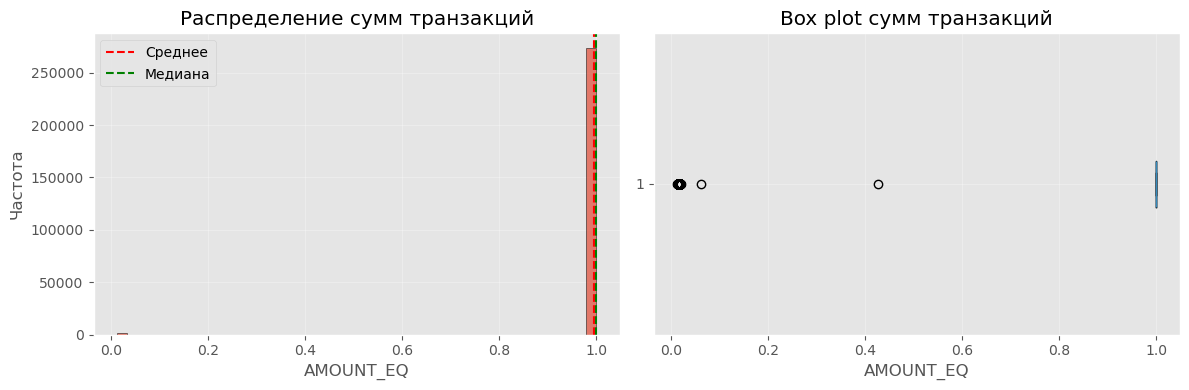

In [111]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew


amounts = data['EXCHANGE_RATA'].dropna()

print(f"Среднее: {amounts.mean():.2f}")
print(f"Медиана: {amounts.median():.2f}")
print(f"Мода: {amounts.mode().values[0]:.2f}")
print(f"Коэффициент асимметрии: {skew(amounts):.2f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(amounts, bins=50, edgecolor='black', alpha=0.7)
axes[0].axvline(amounts.mean(), color='red', linestyle='--', label='Среднее')
axes[0].axvline(amounts.median(), color='green', linestyle='--', label='Медиана')
axes[0].set_xlabel('AMOUNT_EQ')
axes[0].set_ylabel('Частота')
axes[0].set_title('Распределение сумм транзакций')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].boxplot(amounts, vert=False)
axes[1].set_xlabel('AMOUNT_EQ')
axes[1].set_title('Box plot сумм транзакций')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [112]:
data['CurrencyName'].unique()

array(['Рубль', 'Доллар США', 'Чешская крона', 'Евро', 'Злотый'],
      dtype=object)

In [113]:
data[data['CurrencyName'] == 'Чешская крона']["EXCHANGE_RATA"]

188059    0.426374
Name: EXCHANGE_RATA, dtype: float64

In [114]:
data['MCC'].nunique()
print(data['MCC'].nunique())

247


In [115]:
print("Минимальная дата:", data['DATE'].min())
print("Максимальная дата:", data['DATE'].max())
print("Пропущенные значения в DATE:", data['DATE'].isna().sum())

Минимальная дата: 2017-05-01 00:00:00
Максимальная дата: 2019-01-31 00:00:00
Пропущенные значения в DATE: 0


In [116]:
print("Уникальные клиенты:", data['ACCOUNT_ID'].nunique())
print("Транзакции на клиента:")
print(data['ACCOUNT_ID'].value_counts().describe())

Уникальные клиенты: 1239
Транзакции на клиента:
count    1239.000000
mean      222.162228
std       314.726022
min         3.000000
25%        18.000000
50%        84.000000
75%       317.000000
max      2885.000000
Name: count, dtype: float64


In [117]:
onehot_cols = ['PaymentSystem', 'OpType', 'DETAILEDCARDTYPE', 'TRANMETHOD', 'ISOWNTERMINAL', 'NAME', 'MCC', 'DEVICETYPE', 'CurrencyName', 'CITY', 'REGION', 'ISVIRTUALTRANSACTION']
cat_feat_names = ['ACCOUNT_ID', 'TERMINAL_CODE', 'CARD', 'TRANS_DETAIL']
num_feat_names = ['AMOUNT_EQ', 'HOUR', 'MINUTE', 'SECOND', 'EXCHANGE_RATA']
log1p_transform_cols = ['AMOUNT_EQ', 'EXCHANGE_RATA']  # если суммы имеют skewed распределение
date_feature = 'DATE'
time_feature = 'TRANS_TIME'
client_id = 'ACCOUNT_ID'
mcc_name = 'MCC'
latent_dim = {'onehot': 128, 'categorical': 16, 'numerical': 4, 'cv': 32}

In [118]:
print("Размер исходных данных:", data.shape)
print("Уникальные клиенты:", data[client_id].nunique())
print("Пропуски в client_id:", data[client_id].isna().sum())
print("Пропуски в date_feature:", data[date_feature].isna().sum())

# Проверим распределение транзакций по клиентам
client_transactions = data[client_id].value_counts()
print("\nРаспределение транзакций по клиентам:")
print(client_transactions.describe())

# Сколько клиентов имеют достаточно транзакций
min_transactions = 2  # минимум для вычисления интервалов
enough_data_clients = client_transactions[client_transactions >= min_transactions]
print(f"Клиенты с ≥{min_transactions} транзакциями: {len(enough_data_clients)}")

# Дополнительная диагностика
print(f"\nДополнительная информация:")
print(f"Тип данных {date_feature}: {data[date_feature].dtype}")
print(f"Тип данных {client_id}: {data[client_id].dtype}")

# Проверим первые несколько значений
print(f"\nПервые 5 значений {date_feature}:")
print(data[date_feature].head())
print(f"\nПервые 5 значений {client_id}:")
print(data[client_id].head())

Размер исходных данных: (275259, 36)
Уникальные клиенты: 1239
Пропуски в client_id: 0
Пропуски в date_feature: 0

Распределение транзакций по клиентам:
count    1239.000000
mean      222.162228
std       314.726022
min         3.000000
25%        18.000000
50%        84.000000
75%       317.000000
max      2885.000000
Name: count, dtype: float64
Клиенты с ≥2 транзакциями: 1239

Дополнительная информация:
Тип данных DATE: datetime64[ns]
Тип данных ACCOUNT_ID: object

Первые 5 значений DATE:
122341   2017-05-01
126090   2017-05-01
133771   2017-05-01
136893   2017-05-01
141279   2017-05-01
Name: DATE, dtype: datetime64[ns]

Первые 5 значений ACCOUNT_ID:
122341    4402417
126090    1430748
133771    1430356
136893    6751581
141279    1433184
Name: ACCOUNT_ID, dtype: object


In [119]:

X_emb, X_oh, cond_vector, synth_date, scaler_cat, scaler_onehot, scaler_num, cv_params, scaler, round_array = \
            trgan.embeddings(data, cat_feat_names, num_feat_names, onehot_cols, date_feature, time_feature, client_id, latent_dim, device=DEVICE, load=False, epochs=60, directory='Pretrains_sber_one_file/')

Loss E_oh: 7.890888082329184e-05: 100%|██████████| 60/60 [03:58<00:00,  3.97s/it] 


OutOfMemoryError: CUDA out of memory. Tried to allocate 424.00 MiB. GPU 0 has a total capacity of 11.99 GiB of which 0 bytes is free. Of the allocated memory 25.85 GiB is allocated by PyTorch, and 16.45 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)

In [ ]:

dim_noise = 20
generator, supervisor, loss_array = trgan.train(X_emb, cond_vector, latent_dim, dim_noise, epochs=60, load=False, experiment_id='sber', DIRECTORY='Pretrains_sber_one_file/')

Discriminator Loss: -0.04705 || Discriminator 2 Loss: -0.02766 || Generator Loss: 0.06072 || Supervisor Loss: 0.10137: 100%|██████████| 1/1 [00:05<00:00,  5.88s/it]


In [ ]:
n_samples = len(X_emb[:]) + 1000
print(n_samples)
synth_data, synth_date, params = sample(n_samples, generator, supervisor, dim_noise, cond_vector, X_emb, cv_params['encoder'], data,\
                                date_feature, client_id, cv_params=cv_params, device=DEVICE)



X_emb1 = scaler.inverse_transform(X_emb)
synth_data = scaler.inverse_transform(synth_data)
print(synth_data)
synth_df = inverse_transform(synth_data, latent_dim, X_oh.columns, scaler_onehot, scaler_cat, scaler_num, cat_feat_names,
                             mcc_name, num_feat_names, True, synth_date, time_feature, round_array, device=DEVICE)


276259
[[ 0.35735846 -0.6103053   0.08731125 ...  0.33246788  0.89980096
   0.91166764]
 [ 0.14654832 -0.48888642  0.24262959 ...  0.33787003  0.88057023
   0.8712437 ]
 [ 0.66183233 -0.7381198  -0.1577274  ...  0.6253982   0.92637396
   0.909538  ]
 ...
 [ 0.43011314 -0.8716677  -0.22478434 ...  0.4994128   0.93830466
   0.8817989 ]
 [ 0.5383519  -0.5894764  -0.00609986 ...  0.709706    0.9079329
   0.8588001 ]
 [ 0.6289591  -0.8716574  -0.537731   ...  0.5208232   0.92783886
   0.87836313]]


In [ ]:
synth_df['CurrencyName'].unique()

array(['Рубль'], dtype=object)

In [ ]:
print(n_samples)

276259


In [ ]:
synth_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 276259 entries, 0 to 276258
Data columns (total 20 columns):
 #   Column                Non-Null Count   Dtype         
---  ------                --------------   -----         
 0   PaymentSystem         276259 non-null  object        
 1   OpType                276259 non-null  object        
 2   DETAILEDCARDTYPE      276259 non-null  object        
 3   TRANMETHOD            276259 non-null  object        
 4   ISOWNTERMINAL         276259 non-null  object        
 5   NAME                  276259 non-null  object        
 6   MCC                   276259 non-null  object        
 7   DEVICETYPE            276259 non-null  object        
 8   CurrencyName          276259 non-null  object        
 9   CITY                  276259 non-null  object        
 10  REGION                276259 non-null  object        
 11  ISVIRTUALTRANSACTION  276259 non-null  object        
 12  ACCOUNT_ID            276259 non-null  object        
 13 

In [ ]:
print(X_oh.columns)

Index(['PaymentSystem_MasterCard', 'PaymentSystem_VISA International',
       'PaymentSystem_БАНК', 'PaymentSystem_МИР - НСПК', 'OpType_Возврат',
       'OpType_Оплата', 'OpType_Отмена операции', 'OpType_Перевод',
       'OpType_Поступление средств', 'OpType_Снятие наличных',
       ...
       'CITY_Шлиссельбург', 'CITY_Шушары', 'REGION_UNKNOWN', 'REGION_VIRTUAL',
       'REGION_Санкт-Петербург', 'REGION_обл Калининградская',
       'REGION_обл Ленинградская', 'REGION_обл Новгородская',
       'ISVIRTUALTRANSACTION_0', 'ISVIRTUALTRANSACTION_1'],
      dtype='object', length=403)


In [ ]:
synth_df.to_csv('Data/synth_sber.csv', 
          index=False,           # Не записывать индексы
          sep=',',               # Разделитель
          encoding='utf-8',      # Кодировка
          header=True,           # Записывать заголовки
          na_rep='NULL')         # Замена NaN значений

In [ ]:
# for i in range(latent_dim['onehot'],X_emb1.shape[1]):
#     plt.hist(X_emb1[:, i], bins=40, alpha=0.7, density=True)
#     plt.hist(synth_data[:, i], bins=40, alpha=0.7, density=True)

#     plt.show()

In [ ]:
synth_df['DETAILEDCARDTYPE']

0         МИР Классическая Зарплатная
1             Visa Classic_инд.дизайн
2         МИР Классическая Зарплатная
3                    MasterCard World
4                    MasterCard World
                     ...             
276254          MasterCard Unembossed
276255          MasterCard Unembossed
276256          MasterCard Unembossed
276257        Visa Classic Unembossed
276258               MasterCard World
Name: DETAILEDCARDTYPE, Length: 276259, dtype: object

In [ ]:
cat_feat_names

['ACCOUNT_ID', 'TERMINAL_CODE', 'CARD', 'TRANS_DETAIL']

In [ ]:

# plot_hist_categorical(data, synth_df, "CustomerKey", 100)

In [ ]:
# plot_hist_categorical(data, synth_df, "ID", 5000)

In [ ]:
# synth_df.head()

In [ ]:
# synth_df["DEVICETYPE"].unique()

In [ ]:
# data["DEVICETYPE"].unique()

In [ ]:
# plot_hist_onehot(data, synth_df, "DEVICETYPE")
# plt.hist(data["ADDRESS"], alpha=0.6, label='Real', bins=np.arange(0, data["ADDRESS"].value_counts().shape[0], 10), color='black', rwidth=0.8, density=True)

In [ ]:
# plot_hist_categorical(data, synth_df, "ADDRESS", 100)


In [ ]:
# plot_hist_categorical(data, synth_df, "TERMINAL_CODE", 5000)

In [ ]:
# plot_hist_categorical(data, synth_df, "TRANS_DETAIL", 500)

In [ ]:
# plot_hist_categorical(data, synth_df, "ACCOUNT_ID", 50)

In [ ]:
# plot_hist_categorical(data, synth_df, "CARD", 50)

In [ ]:
num_feat_names

['AMOUNT_EQ', 'HOUR', 'MINUTE', 'SECOND', 'EXCHANGE_RATA']

In [ ]:
# plot_hist_numerical(data, synth_df, 'AMOUNT_EQ', tick=100)

In [ ]:
# evaluate_numerical([data['AMOUNT_EQ'], synth_df['AMOUNT_EQ']], ['Real', 'TRGAN'])

In [ ]:
onehot_cols

['PaymentSystem', 'OpType', 'DETAILED_CARD_TYPE', 'TRAN_METHOD', 'ISOWNTERMINAL', 'NAME', 'MCC']

['PaymentSystem',
 'OpType',
 'DETAILED_CARD_TYPE',
 'TRAN_METHOD',
 'ISOWNTERMINAL',
 'NAME',
 'MCC']

In [ ]:
# plot_hist_onehot(data, synth_df, 'MCC')

In [ ]:
# plot_hist_onehot(data, synth_df, 'NAME')

In [ ]:
# plot_hist_onehot(data, synth_df, 'ISOWNTERMINAL')

In [ ]:
# synth_df['TRANMETHOD'].unique()

In [ ]:
# plot_hist_onehot(data, synth_df, 'TRANMETHOD')

In [ ]:
# plot_hist_onehot(data, synth_df, 'DETAILEDCARDTYPE')

In [ ]:
# plot_hist_onehot(data, synth_df, 'OpType')

In [ ]:
# plot_hist_onehot(data, synth_df, 'PaymentSystem')